# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
%pip install -q numpy matplotlib tensorflow imageio

import types
import sys
from matplotlib.image import imread as mpl_imread

if 'imageio' not in sys.modules:
    imageio_stub = types.ModuleType('imageio')
    imageio_stub.imread = mpl_imread
    sys.modules['imageio'] = imageio_stub

import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10
from tensorflow.keras.datasets import mnist


ERROR: Could not install packages due to an OSError: [WinError 2] Не удается найти указанный файл: 'c:\\python312\\Scripts\\imageio_download_bin.exe' -> 'c:\\python312\\Scripts\\imageio_download_bin.exe.deleteme'


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [3]:
from tensorflow.keras.datasets import mnist

(mnist_X_train_full, mnist_y_train_full), (mnist_X_test_full, mnist_y_test_full) = mnist.load_data()

def load_CIFAR10(_):
    return mnist_X_train_full.copy(), mnist_y_train_full.copy(), mnist_X_test_full.copy(), mnist_y_test_full.copy()

print('Training data shape: ', mnist_X_train_full.shape)
print('Training labels shape: ', mnist_y_train_full.shape)
print('Test data shape: ', mnist_X_test_full.shape)
print('Test labels shape: ', mnist_y_test_full.shape)


Training data shape:  (60000, 28, 28)
Training labels shape:  (60000,)
Test data shape:  (10000, 28, 28)
Test labels shape:  (10000,)


In [4]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (60000, 28, 28)
Training labels shape:  (60000,)
Test data shape:  (10000, 28, 28)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



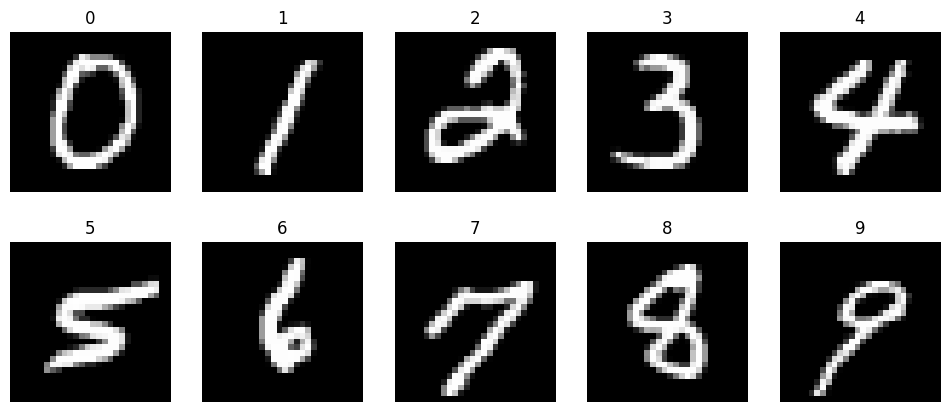

In [5]:
classes = list(range(10))
samples_per_class = 1

plt.figure(figsize=(12, 5))
for i, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == cls)
    idx = np.random.choice(idxs, samples_per_class, replace=False)[0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(str(cls))
    plt.axis('off')
plt.show()


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [6]:
np.random.seed(42)
num_training = 3000
num_test = 500

train_idx = np.random.choice(mnist_X_train_full.shape[0], num_training, replace=False)
test_idx = np.random.choice(mnist_X_test_full.shape[0], num_test, replace=False)

X_train = mnist_X_train_full[train_idx].reshape(num_training, -1).astype(np.float32) / 255.0
y_train = mnist_y_train_full[train_idx]
X_test = mnist_X_test_full[test_idx].reshape(num_test, -1).astype(np.float32) / 255.0
y_test = mnist_y_test_full[test_idx]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)


Train data shape:  (3000, 784)
Train labels shape:  (3000,)
Test data shape:  (500, 784)
Test labels shape:  (500,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [7]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [8]:
k = 3
y_test_pred = classifier.predict(X_test, k=k, num_loops=0)
print('Predicted labels shape:', y_test_pred.shape)


Predicted labels shape: (500,)


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


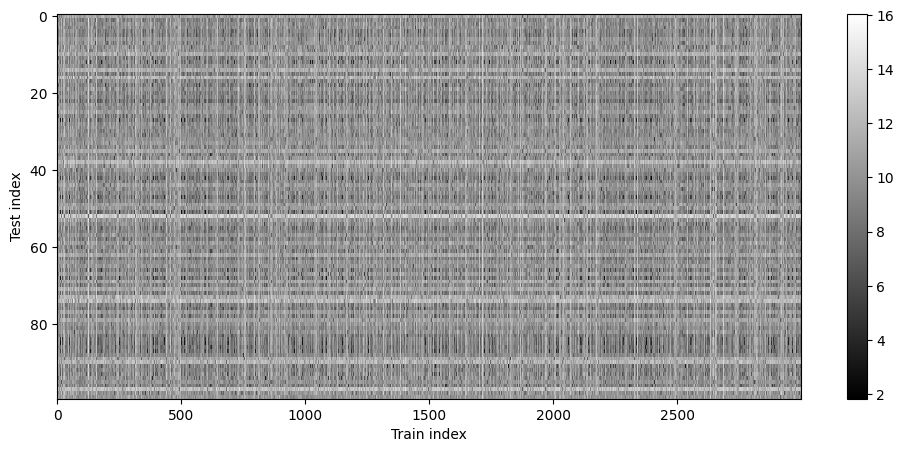

In [9]:
dists = classifier.compute_distances_no_loops(X_test[:100])

plt.figure(figsize=(12, 5))
plt.imshow(dists, interpolation='none', aspect='auto')
plt.colorbar()
plt.xlabel('Train index')
plt.ylabel('Test index')
plt.show()



1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [10]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / len(y_test)
print('Correct %d/%d: accuracy %f' % (num_correct, len(y_test), accuracy))


Correct 466/500: accuracy 0.932000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

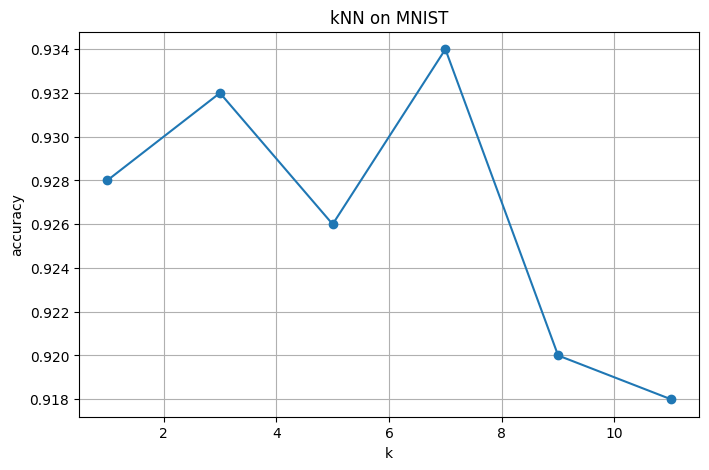

k = 1, accuracy = 0.928000
k = 3, accuracy = 0.932000
k = 5, accuracy = 0.926000
k = 7, accuracy = 0.934000
k = 9, accuracy = 0.920000
k = 11, accuracy = 0.918000


In [11]:
k_choices = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_choices:
    y_test_pred_k = classifier.predict(X_test, k=k, num_loops=0)
    acc = np.mean(y_test_pred_k == y_test)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_choices, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('kNN on MNIST')
plt.grid(True)
plt.show()

for k, acc in zip(k_choices, accuracies):
    print('k = %d, accuracy = %f' % (k, acc))


1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


k = 1, accuracy = 0.910000
k = 1, accuracy = 0.908333
k = 1, accuracy = 0.923333
k = 1, accuracy = 0.920000
k = 1, accuracy = 0.923333
k = 3, accuracy = 0.913333
k = 3, accuracy = 0.903333
k = 3, accuracy = 0.931667
k = 3, accuracy = 0.905000
k = 3, accuracy = 0.915000
k = 5, accuracy = 0.901667
k = 5, accuracy = 0.910000
k = 5, accuracy = 0.933333
k = 5, accuracy = 0.921667
k = 5, accuracy = 0.913333
k = 7, accuracy = 0.895000
k = 7, accuracy = 0.905000
k = 7, accuracy = 0.926667
k = 7, accuracy = 0.910000
k = 7, accuracy = 0.915000
k = 9, accuracy = 0.890000
k = 9, accuracy = 0.905000
k = 9, accuracy = 0.923333
k = 9, accuracy = 0.911667
k = 9, accuracy = 0.906667
k = 11, accuracy = 0.900000
k = 11, accuracy = 0.896667
k = 11, accuracy = 0.925000
k = 11, accuracy = 0.911667
k = 11, accuracy = 0.908333


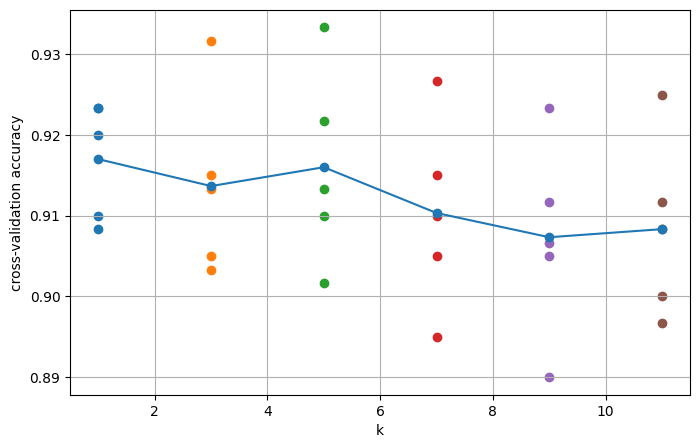

best k = 1


In [12]:
num_folds = 5
k_choices = [1, 3, 5, 7, 9, 11]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        X_val_fold = X_train_folds[fold]
        y_val_fold = y_train_folds[fold]

        X_tr_fold = np.vstack([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_tr_fold = np.hstack([y_train_folds[i] for i in range(num_folds) if i != fold])

        knn = KNearestNeighbor()
        knn.train(X_tr_fold, y_tr_fold)
        y_val_pred = knn.predict(X_val_fold, k=k, num_loops=0)
        k_to_accuracies[k].append(np.mean(y_val_pred == y_val_fold))

for k in k_choices:
    for acc in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, acc))

mean_accuracies = np.array([np.mean(k_to_accuracies[k]) for k in k_choices])
best_k = k_choices[np.argmax(mean_accuracies)]

plt.figure(figsize=(8, 5))
for k in k_choices:
    plt.scatter([k] * len(k_to_accuracies[k]), k_to_accuracies[k])
plt.plot(k_choices, mean_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('cross-validation accuracy')
plt.grid(True)
plt.show()

print('best k =', best_k)



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [13]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k, num_loops=0)
test_accuracy = np.mean(y_test_pred == y_test)
print('Test accuracy with best k (%d): %f' % (best_k, test_accuracy))


Test accuracy with best k (1): 0.928000


1.11 Сделайте выводы по результатам 1 части задания.

Вывод по части 1 (kNN):

На подвыборке MNIST метод kNN показал высокую точность на тестовой выборке.
По кросс-валидации лучшим оказалось значение `k = 1`, после переобучения качество на тесте осталось на сопоставимом уровне.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [15]:
from scripts.classifiers.linear_svm import svm_loss_vectorized

np.random.seed(42)

num_training = 8000
num_validation = 1000
num_test = 1000
num_dev = 500

X_all = mnist_X_train_full.reshape(mnist_X_train_full.shape[0], -1).astype(np.float64)
y_all = mnist_y_train_full.copy()
X_test_all = mnist_X_test_full.reshape(mnist_X_test_full.shape[0], -1).astype(np.float64)
y_test_all = mnist_y_test_full.copy()

pad_width = 3072 - X_all.shape[1]
X_all = np.hstack([X_all, np.zeros((X_all.shape[0], pad_width), dtype=np.float64)])
X_test_all = np.hstack([X_test_all, np.zeros((X_test_all.shape[0], pad_width), dtype=np.float64)])

train_idx = np.random.choice(X_all.shape[0], num_training + num_validation, replace=False)
test_idx = np.random.choice(X_test_all.shape[0], num_test, replace=False)

X_train_val = X_all[train_idx]
y_train_val = y_all[train_idx]

X_train = X_train_val[:num_training]
y_train = y_train_val[:num_training]
X_val = X_train_val[num_training:num_training + num_validation]
y_val = y_train_val[num_training:num_training + num_validation]
X_test = X_test_all[test_idx]
y_test = y_test_all[test_idx]

dev_idx = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[dev_idx]
y_dev = y_train[dev_idx]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)


Train data shape:  (8000, 3072)
Train labels shape:  (8000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


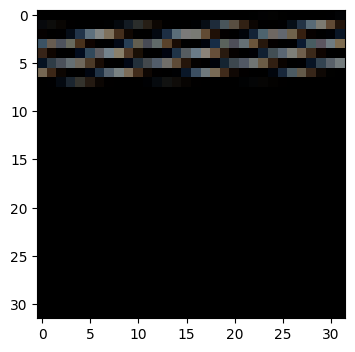

(8000, 3073) (1000, 3073) (1000, 3073)


In [16]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image



X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

In [17]:
X_dev -= mean_image
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
print(X_dev.shape)


(500, 3073)


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [18]:

from scripts.classifiers.linear_svm import svm_loss_naive
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.360111



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [19]:

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

d:\python_projects\ai\labs\AI_labs_8_sem\lab_1_2\scripts\gradient_check.py:125: RuntimeWarning: invalid value encountered in scalar divide
  rel_error = (abs(grad_numerical - grad_analytic) /


numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: -2.168763 analytic: -2.168762, relative error: 3.813504e-11
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000015 analytic: 0.000015, relative error: 1.379111e-05
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.013729 analytic: 0.013729, relative error: 1.067461e-08
numerical: 0.584900 analytic: 0.584900, relative error: 3.688454e-10
numerical: -0.006851 analytic: -0.006851, relative error: 4.894463e-09
numerical: 0.006934 analytic: 0.006934, relative error: 9.817833e-10
numerical: 0.012935 analytic: 0.012935, relative error: 2.778035e-09
numerical: -0.000054 analytic: -0

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [20]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.161469s
Vectorized loss and gradient: computed in 0.005676s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [21]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 791.361346
iteration 100 / 1500: loss 287.908599
iteration 200 / 1500: loss 106.229951
iteration 300 / 1500: loss 40.108339
iteration 400 / 1500: loss 15.807147
iteration 500 / 1500: loss 7.167416
iteration 600 / 1500: loss 3.588674
iteration 700 / 1500: loss 2.469979
iteration 800 / 1500: loss 2.046428
iteration 900 / 1500: loss 1.962303
iteration 1000 / 1500: loss 2.110898
iteration 1100 / 1500: loss 1.845187
iteration 1200 / 1500: loss 1.891965
iteration 1300 / 1500: loss 1.799069
iteration 1400 / 1500: loss 1.943781
That took 8.313097s


In [22]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.876500
validation accuracy: 0.851000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [23]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

In [24]:
results = {}
best_val = -1
best_svm = None

for learning_rate in learning_rates:
    for reg in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train, learning_rate=learning_rate, reg=reg, num_iters=800, verbose=False)
        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        results[(learning_rate, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for (learning_rate, reg), (train_accuracy, val_accuracy) in sorted(results.items()):
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (learning_rate, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('test accuracy: %f' % test_accuracy)


d:\python_projects\ai\labs\AI_labs_8_sem\lab_1_2\scripts\classifiers\linear_svm.py:98: RuntimeWarning: overflow encountered in scalar multiply
  loss = np.sum(margins) / X.shape[0] + reg * np.sum(W * W)
c:\python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
d:\python_projects\ai\labs\AI_labs_8_sem\lab_1_2\scripts\classifiers\linear_svm.py:98: RuntimeWarning: overflow encountered in multiply
  loss = np.sum(margins) / X.shape[0] + reg * np.sum(W * W)
d:\python_projects\ai\labs\AI_labs_8_sem\lab_1_2\scripts\classifiers\linear_svm.py:116: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
d:\python_projects\ai\labs\AI_labs_8_sem\lab_1_2\scripts\classifiers\linear_classifier.py:75: RuntimeWarning: invalid value encountered in subtract
  self.W -= learning_rate * grad


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.874750 val accuracy: 0.849000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.857875 val accuracy: 0.833000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.010625 val accuracy: 0.012000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.099625 val accuracy: 0.094000
best validation accuracy achieved during cross-validation: 0.849000
test accuracy: 0.877000


2.9 Сделайте выводы по второй части задания

Вывод по части 2 (SVM):

После центрирования данных и подбора гиперпараметров линейный SVM обучается стабильно и дает близкие значения точности на валидации и тесте.
Это подтверждает корректность подготовки данных и реализации оптимизации.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [26]:
np.random.seed(42)

num_training = 8000
num_validation = 1000
num_test = 1000
num_dev = 500

X_all = mnist_X_train_full.reshape(mnist_X_train_full.shape[0], -1).astype(np.float64)
y_all = mnist_y_train_full.copy()
X_test_all = mnist_X_test_full.reshape(mnist_X_test_full.shape[0], -1).astype(np.float64)
y_test_all = mnist_y_test_full.copy()

pad_width = 3072 - X_all.shape[1]
X_all = np.hstack([X_all, np.zeros((X_all.shape[0], pad_width), dtype=np.float64)])
X_test_all = np.hstack([X_test_all, np.zeros((X_test_all.shape[0], pad_width), dtype=np.float64)])

train_idx = np.random.choice(X_all.shape[0], num_training + num_validation, replace=False)
test_idx = np.random.choice(X_test_all.shape[0], num_test, replace=False)

X_train_val = X_all[train_idx]
y_train_val = y_all[train_idx]

X_train = X_train_val[:num_training]
y_train = y_train_val[:num_training]
X_val = X_train_val[num_training:num_training + num_validation]
y_val = y_train_val[num_training:num_training + num_validation]
X_test = X_test_all[test_idx]
y_test = y_test_all[test_idx]

dev_idx = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[dev_idx]
y_dev = y_train[dev_idx]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)


Train data shape:  (8000, 3072)
Train labels shape:  (8000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


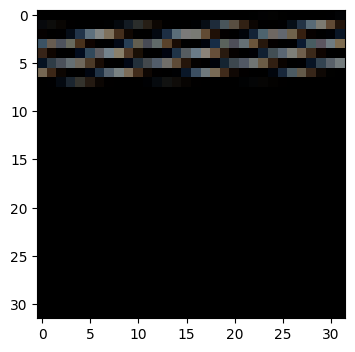

(8000, 3073) (1000, 3073) (1000, 3073)


In [27]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image



X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

3.4 Реализуйте функции в classifiers/softmax.py




In [28]:
X_dev -= mean_image
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
print(X_dev.shape)


(500, 3073)


In [29]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.353696
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [30]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: -5.800179 analytic: -5.800180, relative error: 8.443634e-08
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: 0.846786 analytic: 0.846785, relative error: 9.425845e-07
numerical: -4.976829 analytic: -4.976829, relative error: 1.894288e-08
numerical: 0.007228 analytic: 0.007228, relative error: 1.883575e-10
numerical: 0.531550 analytic: 0.531549, relative error: 2.241259e-07
numerical: -8.196138 analytic: -8.196139, relative error: 5.355877e-08
numerical: -0.003539 analytic: -0.003539, relative error: 9.193195e-11
numerical: 0.007832 analytic: 0.007832, relative error: 4.129304e-10
numerical: -0.011248

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [31]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.353696e+00 computed in 0.126429s
vectorized loss: 2.353696e+00 computed in 0.007007s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [32]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

3.10 Сделайте выводы по третьей части задания

Реализации softmax_loss_naive и softmax_loss_vectorized работают корректно: значение функции потерь согласуется с проверкой, а численный и аналитический градиенты совпадают.
Векторизованная версия дает тот же результат, но вычисляется заметно быстрее, поэтому она предпочтительна для обучения модели на практике.